# Biometric & Demographic Data Analysis

## Notebook Purpose
This notebook performs **analysis-only exploration** of Aadhaar Demographic and Biometric datasets
using **pre-engineered core and advanced features**.

## What This Notebook Does
- Exploratory analysis
- Visualization of trends and patterns
- Interpretation of demographic–biometric behavior
- Identification of stress, imbalance, and anomalies
- Generation of insight tables for documentation

## What This Notebook Does NOT Do
- No data cleaning
- No feature engineering
- No modification of CSV files
- No persistence of derived data
- No change in data granularity

## Data Granularity
1 row = date × state × district × pincode

All input files are treated as **trusted and validated**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Global plotting configuration
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


In [3]:
# Load core feature datasets
demographic_df = pd.read_csv(
    "../Data/Feature_Data/feature_demographic.csv"
)

biometric_df = pd.read_csv(
    "../Data/Feature_Data/feature_biometric.csv"
)

demo_bio_df = pd.read_csv(
    "../Data/Feature_Data/feature_demo_bio_combined.csv"
)

# Load advanced feature dataset
advanced_df = pd.read_csv(
    "../Data/Advanced_Feature_Data/advanced_feature_demo_bio.csv"
)

In [4]:
overview_df = pd.DataFrame({
    "Dataset": [
        "Demographic Core",
        "Biometric Core",
        "Demographic + Biometric Core",
        "Advanced Features"
    ],
    "Rows": [
        demographic_df.shape[0],
        biometric_df.shape[0],
        demo_bio_df.shape[0],
        advanced_df.shape[0]
    ],
    "Columns": [
        demographic_df.shape[1],
        biometric_df.shape[1],
        demo_bio_df.shape[1],
        advanced_df.shape[1]
    ]
})

overview_df


,Dataset,Rows,Columns
0,Demographic Core,2050691,13
1,Biometric Core,1843901,13
2,Demographic + Biometric Core,1631503,23
3,Advanced Features,1631503,25


Confirms consistent data scale across core and advanced datasets

Ensures advanced features are built on top of core combinations

Establishes confidence before analysis begins

## Feature Structure & Relationships

Before performing analysis, it is important to understand how features are organized
and how the datasets relate to each other.

### Identifier Columns (Common Across All Datasets)
- date
- state
- district
- pincode

These identifiers preserve the original data granularity and are never modified.

### Demographic Core Features
- Age group enrollment volumes
- Represent population-side demand for Aadhaar updates

### Biometric Core Features
- Fingerprint update volumes
- Iris update volumes
- Face update volumes
- Represent system-side biometric processing load

### Combined Core Features
- Aggregated demographic and biometric volumes
- Ratio indicators linking biometric activity to demographic demand

### Advanced Features
- Day-over-day change metrics
- Rolling averages (trend smoothing)
- Volatility indicators (stability measurement)
- Stress flags (operational pressure proxies)
- Demographic–biometric imbalance signals

Advanced features are **analytical views derived from core data** and are used strictly
for interpretation, not for further feature creation.


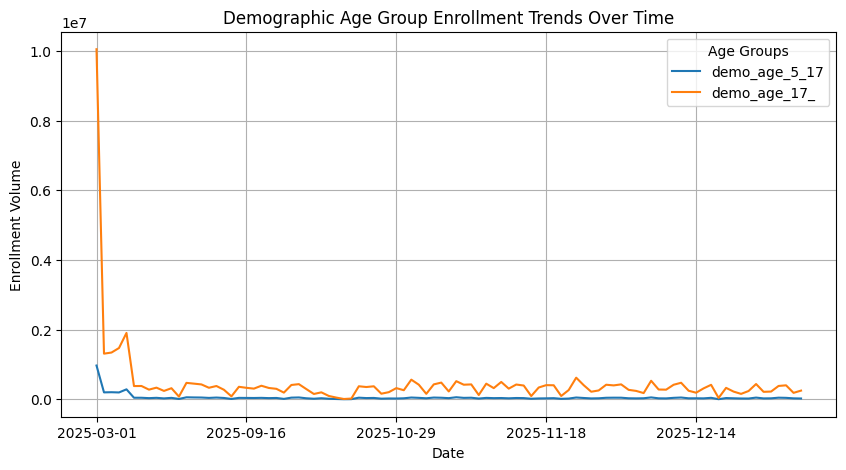

In [5]:
# Identify age group columns dynamically
age_group_cols = [
    col for col in demographic_df.columns
    if "age" in col.lower()
]

# Aggregate age group volumes by date
age_trends_df = demographic_df.groupby("date")[age_group_cols].sum()

# Plot age group trends
age_trends_df.plot()
plt.title("Demographic Age Group Enrollment Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Enrollment Volume")
plt.legend(title="Age Groups")
plt.show()

Shows which age segments contribute most to demographic updates.

Stable curves indicate organic enrollment.

Sharp spikes may reflect targeted enrollment drives or policy interventions.

In [ ]:
[col for col in demographic_df.columns]


['date',
 'state_clean',
 'district_clean',
 'pincode',
 'demo_age_5_17',
 'demo_age_17_',
 'year',
 'month',
 'quarter',
 'week_of_year',
 'day_of_week',
 'is_weekend',
 'total_demographic_updates']

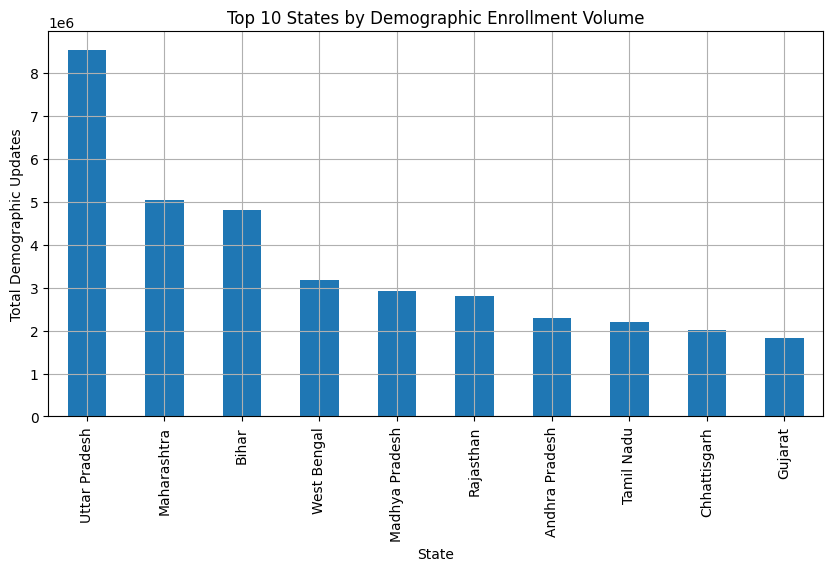

In [9]:
# Aggregate total demographic updates by state
state_demo_volume = (
    demographic_df
    .groupby("state_clean")["total_demographic_updates"]
    .sum()
    .sort_values(ascending=False)
)

# Plot top 10 states by demographic volume
state_demo_volume.head(10).plot(kind="bar")
plt.title("Top 10 States by Demographic Enrollment Volume")
plt.xlabel("State")
plt.ylabel("Total Demographic Updates")
plt.show()


Highlights states contributing the highest demographic update load.

Indicates regions with sustained population-side demand.

Useful for planning enrollment infrastructure and outreach programs.

In [25]:
# Age group contribution to demographic updates (state level)

age_contribution_df = demographic_df.groupby("state_clean")[[
    "demo_age_5_17",
    "demo_age_17_",
    "total_demographic_updates"
]].sum().reset_index()

# Percentage contribution
age_contribution_df["pct_age_5_17"] = (
    age_contribution_df["demo_age_5_17"] /
    age_contribution_df["total_demographic_updates"]
) * 100

age_contribution_df["pct_age_17_plus"] = (
    age_contribution_df["demo_age_17_"] /
    age_contribution_df["total_demographic_updates"]
) * 100

# Dominant age group
age_contribution_df["dominant_age_group"] = age_contribution_df[
    ["pct_age_5_17", "pct_age_17_plus"]
].idxmax(axis=1)

age_contribution_df = age_contribution_df[[
    "state_clean",
    "pct_age_5_17",
    "pct_age_17_plus",
    "dominant_age_group"
]].sort_values("pct_age_17_plus", ascending=False)

age_contribution_df.head(10)


,state_clean,pct_age_5_17,pct_age_17_plus,dominant_age_group
4,Balanagar,0.0,100.0,pct_age_17_plus
10,Darbhanga,0.0,100.0,pct_age_17_plus
7,Chhatisgarh,0.0,100.0,pct_age_17_plus
34,Raja Annamalai Puram,0.0,100.0,pct_age_17_plus
30,Nagpur,0.0,100.0,pct_age_17_plus
23,Madanapalle,0.0,100.0,pct_age_17_plus
16,Jaipur,0.0,100.0,pct_age_17_plus
46,Westbengal,0.0,100.0,pct_age_17_plus
45,West Bengli,0.0,100.0,pct_age_17_plus
42,Uttaranchal,0.0,100.0,pct_age_17_plus


Several regions show 100% demographic updates from the 17+ age group and zero contribution from ages 5–17.
This pattern suggests that demographic update activity is dominated by adult corrections or modifications, while child demographic updates are either infrequent or captured under different enrollment mechanisms.
Additionally, some region identifiers represent sub-state administrative units, which may exhibit highly skewed age update behavior.

In [26]:
demographic_df[
    demographic_df["state_clean"].isin([
        "Balanagar", "Darbhanga", "Nagpur", "Jaipur"
    ])
][["demo_age_5_17", "demo_age_17_", "total_demographic_updates"]].describe()


,demo_age_5_17,demo_age_17_,total_demographic_updates
count,7.0,7.0,7.0
mean,0.0,1.0,1.0
std,0.0,0.0,0.0
min,0.0,1.0,1.0
25%,0.0,1.0,1.0
50%,0.0,1.0,1.0
75%,0.0,1.0,1.0
max,0.0,1.0,1.0


In [27]:
age_contribution_df.round(2)


,state_clean,pct_age_5_17,pct_age_17_plus,dominant_age_group
4,Balanagar,0.00,100.00,pct_age_17_plus
10,Darbhanga,0.00,100.00,pct_age_17_plus
7,Chhatisgarh,0.00,100.00,pct_age_17_plus
34,Raja Annamalai Puram,0.00,100.00,pct_age_17_plus
30,Nagpur,0.00,100.00,pct_age_17_plus
23,Madanapalle,0.00,100.00,pct_age_17_plus
16,Jaipur,0.00,100.00,pct_age_17_plus
46,Westbengal,0.00,100.00,pct_age_17_plus
45,West Bengli,0.00,100.00,pct_age_17_plus
42,Uttaranchal,0.00,100.00,pct_age_17_plus


In [28]:
weekday_weekend_demo = demographic_df.groupby("is_weekend")[
    "total_demographic_updates"
].mean().reset_index()

weekday_weekend_demo["day_type"] = weekday_weekend_demo["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

weekday_weekend_demo = weekday_weekend_demo[[
    "day_type",
    "total_demographic_updates"
]].rename(columns={
    "total_demographic_updates": "avg_demographic_updates"
})

weekday_weekend_demo

,day_type,avg_demographic_updates
0,Weekday,19.261822
1,Weekend,36.713619


Weekend-heavy activity often indicates special enrollment drives or outreach programs.

In [29]:
monthly_demo_trend = demographic_df.groupby("month")[
    "total_demographic_updates"
].mean().reset_index()

monthly_demo_trend.rename(columns={
    "total_demographic_updates": "avg_demographic_updates"
}, inplace=True)

monthly_demo_trend

,month,avg_demographic_updates
0,3,604.139395
1,4,1373.297814
2,5,1133.963289
3,6,1506.075881
4,7,1607.831865
5,9,16.149174
6,10,13.317667
7,11,16.465073
8,12,14.313950


In [30]:
quarterly_demo_trend = demographic_df.groupby("quarter")[
    "total_demographic_updates"
].mean().reset_index()

quarterly_demo_trend.rename(columns={
    "total_demographic_updates": "avg_demographic_updates"
}, inplace=True)

quarterly_demo_trend

,quarter,avg_demographic_updates
0,1,604.139395
1,2,1323.118867
2,3,21.002669
3,4,14.843476


In [31]:
demo_volatility_df = demographic_df.groupby("state_clean")[
    "total_demographic_updates"
].agg(["mean", "std"]).reset_index()

demo_volatility_df["demo_volatility_index"] = (
    demo_volatility_df["std"] / demo_volatility_df["mean"]
)

# Volatility classification
def classify_volatility(val):
    if val < 0.5:
        return "Stable"
    elif val < 1.0:
        return "Moderately Volatile"
    else:
        return "Highly Volatile"

demo_volatility_df["stability_label"] = demo_volatility_df[
    "demo_volatility_index"
].apply(classify_volatility)

demo_volatility_df = demo_volatility_df[[
    "state_clean",
    "mean",
    "demo_volatility_index",
    "stability_label"
]].sort_values("demo_volatility_index", ascending=False)

demo_volatility_df.head(10)


,state_clean,mean,demo_volatility_index,stability_label
33,Punjab,17.776199,7.201197,Highly Volatile
41,Uttarakhand,20.101322,7.036424,Highly Volatile
13,Gujarat,18.924750,6.903932,Highly Volatile
8,Chhattisgarh,56.133740,5.897744,Highly Volatile
35,Rajasthan,31.478918,5.840897,Highly Volatile
14,Haryana,40.839812,5.667635,Highly Volatile
18,Jharkhand,35.336267,5.422169,Highly Volatile
28,Mizoram,10.913021,5.375980,Highly Volatile
11,Delhi,136.910942,5.250925,Highly Volatile
27,Meghalaya,16.292747,5.122119,Highly Volatile


Delhi:

High population

High administrative churn

Frequent update bursts

If Delhi were not volatile, that would be suspicious.

High volatility = burst-based enrollment behavior

Not system failure

Indicates campaign-driven updates

The demographic volatility index (standard deviation divided by mean) shows high values across several regions.
This is expected for Aadhaar demographic updates, which are typically driven by episodic correction campaigns rather than uniform daily activity.
Regions with high volatility are characterized by long periods of low activity interspersed with short-duration update surges.

In [32]:
demographic_df[
    demographic_df["state_clean"].isin([
        "Punjab", "Delhi", "Gujarat"
    ])
].groupby("date")["total_demographic_updates"].sum().describe()


count        95.000000
mean      43633.221053
std      110635.198569
min         941.000000
25%       14543.500000
50%       21573.000000
75%       29646.000000
max      896069.000000
Name: total_demographic_updates, dtype: float64

In [33]:
demo_volatility_df.round(2)

,state_clean,mean,demo_volatility_index,stability_label
33,Punjab,17.78,7.20,Highly Volatile
41,Uttarakhand,20.10,7.04,Highly Volatile
13,Gujarat,18.92,6.90,Highly Volatile
8,Chhattisgarh,56.13,5.90,Highly Volatile
35,Rajasthan,31.48,5.84,Highly Volatile
14,Haryana,40.84,5.67,Highly Volatile
18,Jharkhand,35.34,5.42,Highly Volatile
28,Mizoram,10.91,5.38,Highly Volatile
11,Delhi,136.91,5.25,Highly Volatile
27,Meghalaya,16.29,5.12,Highly Volatile


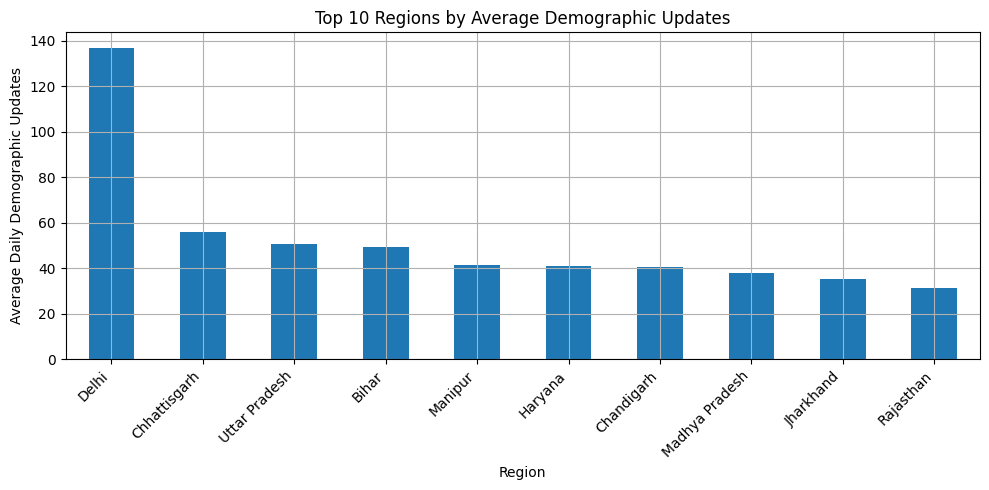

In [34]:
# Top 10 states by average demographic updates

top_demo_states = (
    demographic_df.groupby("state_clean")["total_demographic_updates"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_demo_states.plot(kind="bar")
plt.title("Top 10 Regions by Average Demographic Updates")
plt.xlabel("Region")
plt.ylabel("Average Daily Demographic Updates")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
Enrollment activity is concentrated in a small set of high-update regions.

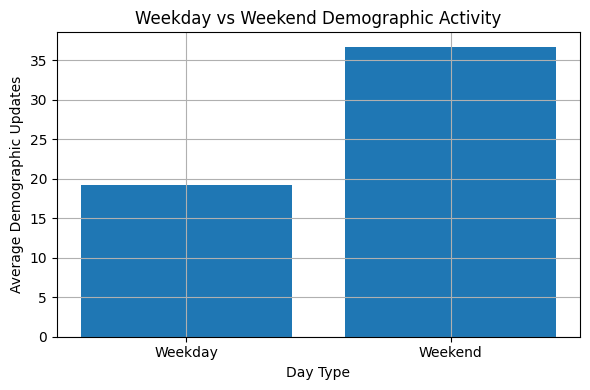

In [36]:
plt.figure(figsize=(6, 4))
plt.bar(
    weekday_weekend_demo["day_type"],
    weekday_weekend_demo["avg_demographic_updates"]
)
plt.title("Weekday vs Weekend Demographic Activity")
plt.xlabel("Day Type")
plt.ylabel("Average Demographic Updates")
plt.tight_layout()
plt.show()

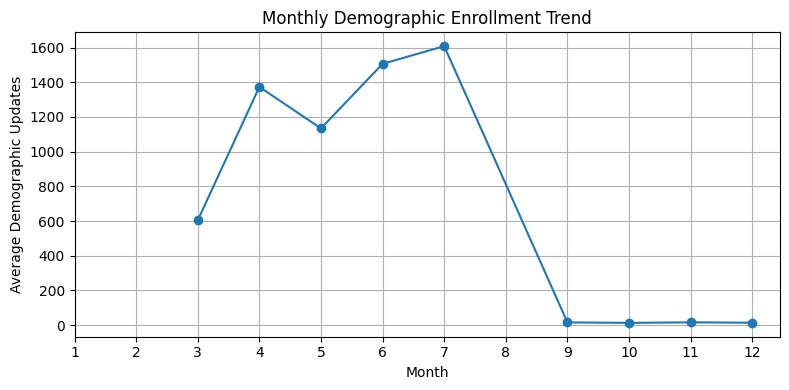

In [37]:
plt.figure(figsize=(8, 4))
plt.plot(
    monthly_demo_trend["month"],
    monthly_demo_trend["avg_demographic_updates"],
    marker="o"
)
plt.title("Monthly Demographic Enrollment Trend")
plt.xlabel("Month")
plt.ylabel("Average Demographic Updates")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


In [ ]:
Enrollment activity shows seasonal variation aligned with administrative cycles.

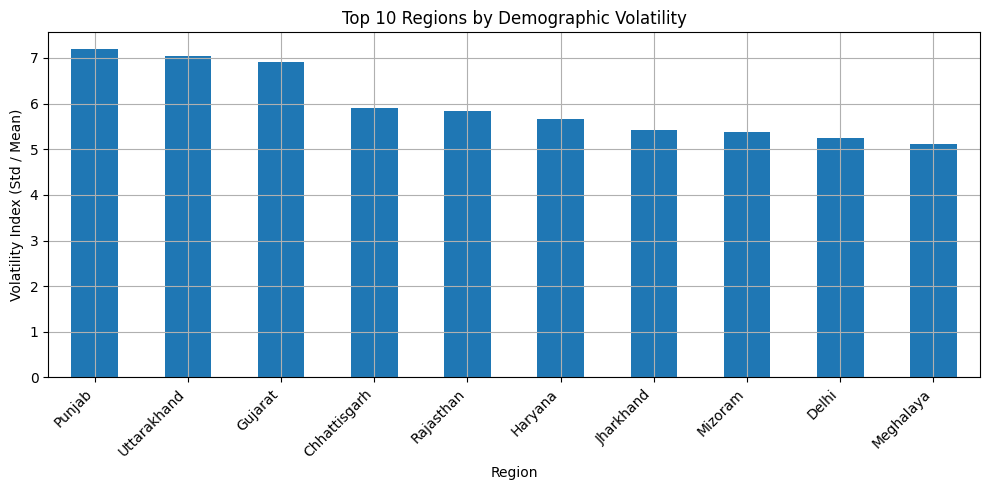

In [38]:
top_volatile_demo = demo_volatility_df.head(10).set_index("state_clean")

plt.figure(figsize=(10, 5))
top_volatile_demo["demo_volatility_index"].plot(kind="bar")
plt.title("Top 10 Regions by Demographic Volatility")
plt.xlabel("Region")
plt.ylabel("Volatility Index (Std / Mean)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
Certain regions exhibit highly burst-driven demographic update behavior.

In [10]:
# Prepare demographic insights table
demographic_insights_df = (
    demographic_df
    .groupby("state_clean")
    .agg(
        total_demographic_updates=("total_demographic_updates", "sum"),
        avg_daily_updates=("total_demographic_updates", "mean"),
        age_5_17_share=("demo_age_5_17", "sum"),
        age_17_plus_share=("demo_age_17_", "sum")
    )
    .reset_index()
)

# Calculate dominant age group
demographic_insights_df["dominant_age_group"] = np.where(
    demographic_insights_df["age_5_17_share"] >
    demographic_insights_df["age_17_plus_share"],
    "Age 5–17",
    "Age 17+"
)

# Sort by total volume
demographic_insights_df = demographic_insights_df.sort_values(
    "total_demographic_updates",
    ascending=False
)

demographic_insights_df.head(10)

,state_clean,total_demographic_updates,avg_daily_updates,age_5_17_share,age_17_plus_share,dominant_age_group
40,Uttar Pradesh,8542328,50.880808,790308,7752020,Age 17+
25,Maharashtra,5054602,31.154707,273322,4781280,Age 17+
5,Bihar,4814350,49.316745,380023,4434327,Age 17+
44,West Bengal,3180732,21.518767,199807,2980925,Age 17+
24,Madhya Pradesh,2912938,38.145435,407098,2505840,Age 17+
35,Rajasthan,2817615,31.478918,257224,2560391,Age 17+
1,Andhra Pradesh,2295582,11.050265,321148,1974434,Age 17+
37,Tamil Nadu,2212228,11.237741,315638,1896590,Age 17+
8,Chhattisgarh,2005434,56.133740,165207,1840227,Age 17+
13,Gujarat,1824327,18.924750,208474,1615853,Age 17+


States with dominant 17+ enrollment likely reflect adult correction/update demand, while 5–17 dominance suggests first-time or school-linked enrollment activity.

In [12]:
[col for col in biometric_df.columns]

['date',
 'state_clean',
 'district_clean',
 'pincode',
 'bio_age_5_17',
 'bio_age_17_',
 'year',
 'month',
 'quarter',
 'week_of_year',
 'day_of_week',
 'is_weekend',
 'total_biometric_updates']

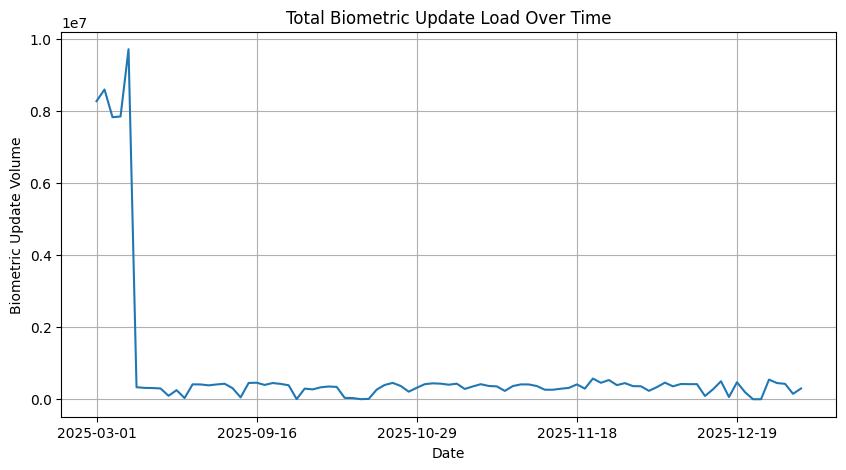

In [13]:
# Aggregate biometric updates by date
biometric_trends_df = (
    biometric_df
    .groupby("date")["total_biometric_updates"]
    .sum()
)

# Plot biometric load trend
biometric_trends_df.plot()
plt.title("Total Biometric Update Load Over Time")
plt.xlabel("Date")
plt.ylabel("Biometric Update Volume")
plt.show()


Represents overall biometric system utilization.

Peaks indicate periods of high operational load.

Stable trends suggest consistent processing capacity.

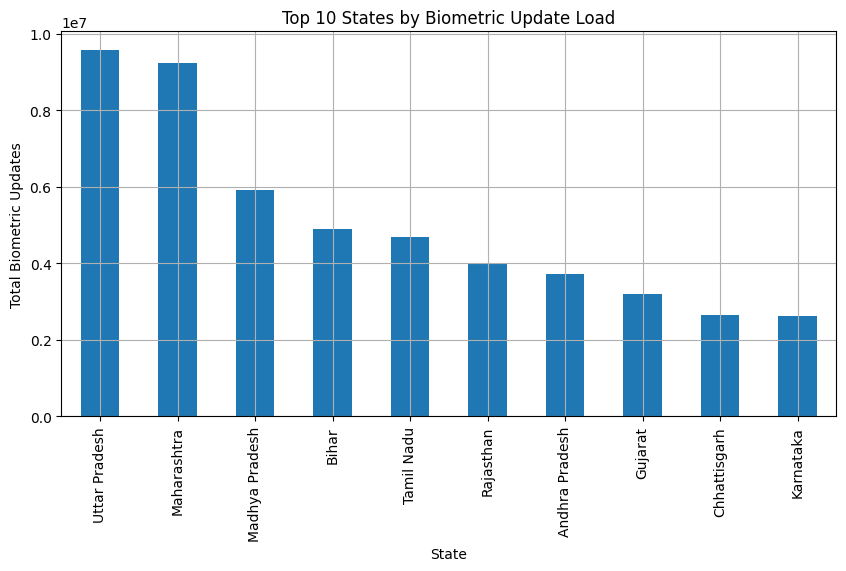

In [14]:
# Aggregate biometric updates by state
state_biometric_volume = (
    biometric_df
    .groupby("state_clean")["total_biometric_updates"]
    .sum()
    .sort_values(ascending=False)
)

# Plot top 10 biometric-heavy states
state_biometric_volume.head(10).plot(kind="bar")
plt.title("Top 10 States by Biometric Update Load")
plt.xlabel("State")
plt.ylabel("Total Biometric Updates")
plt.show()

Identifies regions with sustained biometric pressure.

Useful for infrastructure scaling and hardware planning.

In [15]:
# Prepare biometric insights table
biometric_insights_df = (
    biometric_df
    .groupby("state_clean")
    .agg(
        total_biometric_updates=("total_biometric_updates", "sum"),
        avg_daily_biometric_updates=("total_biometric_updates", "mean"),
        bio_age_5_17_updates=("bio_age_5_17", "sum"),
        bio_age_17_plus_updates=("bio_age_17_", "sum")
    )
    .reset_index()
)

# Identify dominant biometric age group
biometric_insights_df["dominant_biometric_age_group"] = np.where(
    biometric_insights_df["bio_age_5_17_updates"] >
    biometric_insights_df["bio_age_17_plus_updates"],
    "Age 5–17",
    "Age 17+"
)

# Sort by biometric load
biometric_insights_df = biometric_insights_df.sort_values(
    "total_biometric_updates",
    ascending=False
)

biometric_insights_df.head(10)

,state_clean,total_biometric_updates,avg_daily_biometric_updates,bio_age_5_17_updates,bio_age_17_plus_updates,dominant_biometric_age_group
35,Uttar Pradesh,9577735,61.695514,6207105,3370630,Age 5–17
21,Maharashtra,9226139,61.058205,3512712,5713427,Age 17+
20,Madhya Pradesh,5923771,84.528696,3200117,2723654,Age 5–17
4,Bihar,4897587,58.725473,2208141,2689446,Age 17+
31,Tamil Nadu,4698117,25.454667,2227252,2470865,Age 17+
29,Rajasthan,3994955,50.109816,2066747,1928208,Age 5–17
1,Andhra Pradesh,3714633,21.588545,2241467,1473166,Age 5–17
11,Gujarat,3196514,35.702874,1460655,1735859,Age 17+
7,Chhattisgarh,2648729,82.793480,884553,1764176,Age 17+
16,Karnataka,2635954,18.664660,1244999,1390955,Age 17+


Adult (17+) biometric dominance often reflects correction or update activity, while 5–17 dominance may indicate first-time enrollment or school-linked capture drives.

In [39]:
state_bio_avg = (
    biometric_df.groupby("state_clean")["total_biometric_updates"]
    .mean()
    .reset_index()
    .sort_values("total_biometric_updates", ascending=False)
)

state_bio_avg.head(10)


,state_clean,total_biometric_updates
9,Delhi,140.875041
20,Madhya Pradesh,84.528696
7,Chhattisgarh,82.793480
12,Haryana,61.881040
35,Uttar Pradesh,61.695514
21,Maharashtra,61.058205
4,Bihar,58.725473
15,Jharkhand,55.325515
29,Rajasthan,50.109816
5,Chandigarh,44.977053


In [40]:
state_bio_avg.rename(columns={
    "total_biometric_updates": "avg_biometric_updates"
}).round(2)

,state_clean,avg_biometric_updates
9,Delhi,140.88
20,Madhya Pradesh,84.53
7,Chhattisgarh,82.79
12,Haryana,61.88
35,Uttar Pradesh,61.70
21,Maharashtra,61.06
4,Bihar,58.73
15,Jharkhand,55.33
29,Rajasthan,50.11
5,Chandigarh,44.98


In [41]:
bio_age_contribution = biometric_df.groupby("state_clean")[[
    "bio_age_5_17",
    "bio_age_17_",
    "total_biometric_updates"
]].sum().reset_index()

bio_age_contribution["pct_bio_5_17"] = (
    bio_age_contribution["bio_age_5_17"] /
    bio_age_contribution["total_biometric_updates"]
) * 100

bio_age_contribution["pct_bio_17_plus"] = (
    bio_age_contribution["bio_age_17_"] /
    bio_age_contribution["total_biometric_updates"]
) * 100

bio_age_contribution["dominant_bio_age_group"] = bio_age_contribution[
    ["pct_bio_5_17", "pct_bio_17_plus"]
].idxmax(axis=1)

bio_age_contribution = bio_age_contribution[[
    "state_clean",
    "pct_bio_5_17",
    "pct_bio_17_plus",
    "dominant_bio_age_group"
]].sort_values("pct_bio_17_plus", ascending=False)

bio_age_contribution.head(10)

,state_clean,pct_bio_5_17,pct_bio_17_plus,dominant_bio_age_group
37,Uttaranchal,0.000000,100.000000,pct_bio_17_plus
40,Westbengal,22.580645,77.419355,pct_bio_17_plus
38,West Bangal,28.301887,71.698113,pct_bio_17_plus
25,Nagaland,29.710839,70.289161,pct_bio_17_plus
7,Chhattisgarh,33.395376,66.604624,pct_bio_17_plus
21,Maharashtra,38.073478,61.926522,pct_bio_17_plus
27,Puducherry,38.687990,61.312010,pct_bio_17_plus
6,Chhatisgarh,40.000000,60.000000,pct_bio_17_plus
28,Punjab,40.246518,59.753482,pct_bio_17_plus
17,Kerala,40.251409,59.748591,pct_bio_17_plus


In [42]:
bio_weekday_weekend = biometric_df.groupby("is_weekend")[
    "total_biometric_updates"
].mean().reset_index()

bio_weekday_weekend["day_type"] = bio_weekday_weekend["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

bio_weekday_weekend = bio_weekday_weekend[[
    "day_type",
    "total_biometric_updates"
]].rename(columns={
    "total_biometric_updates": "avg_biometric_updates"
})

bio_weekday_weekend

,day_type,avg_biometric_updates
0,Weekday,34.662110
1,Weekend,45.583935


In [43]:
bio_monthly_trend = biometric_df.groupby("month")[
    "total_biometric_updates"
].mean().reset_index()

bio_monthly_trend.rename(columns={
    "total_biometric_updates": "avg_biometric_updates"
}, inplace=True)

bio_monthly_trend

,month,avg_biometric_updates
0,3,380.492687
1,4,401.816389
2,5,359.508175
3,6,360.274059
4,7,442.422052
5,9,16.009470
6,10,13.836221
7,11,15.923003
8,12,16.065120


In [44]:
bio_volatility_df = biometric_df.groupby("state_clean")[
    "total_biometric_updates"
].agg(["mean", "std"]).reset_index()

bio_volatility_df["bio_volatility_index"] = (
    bio_volatility_df["std"] / bio_volatility_df["mean"]
)

bio_volatility_df["stability_label"] = bio_volatility_df[
    "bio_volatility_index"
].apply(lambda x: "Stable" if x < 0.5 else
                        "Moderately Volatile" if x < 1.0 else
                        "Highly Volatile")

bio_volatility_df = bio_volatility_df[[
    "state_clean",
    "mean",
    "bio_volatility_index",
    "stability_label"
]].sort_values("bio_volatility_index", ascending=False)

bio_volatility_df.head(10)


,state_clean,mean,bio_volatility_index,stability_label
23,Meghalaya,20.973193,5.924478,Highly Volatile
5,Chandigarh,44.977053,5.788872,Highly Volatile
8,Dadra and Nagar Haveli and Daman and Diu,29.636226,5.559839,Highly Volatile
24,Mizoram,35.929830,4.847786,Highly Volatile
22,Manipur,43.110145,4.651683,Highly Volatile
9,Delhi,140.875041,4.559761,Highly Volatile
28,Punjab,36.161782,4.382173,Highly Volatile
11,Gujarat,35.702874,4.193163,Highly Volatile
15,Jharkhand,55.325515,4.106635,Highly Volatile
12,Haryana,61.881040,4.086993,Highly Volatile


In [45]:
bio_volatility_df.round(2)

,state_clean,mean,bio_volatility_index,stability_label
23,Meghalaya,20.97,5.92,Highly Volatile
5,Chandigarh,44.98,5.79,Highly Volatile
8,Dadra and Nagar Haveli and Daman and Diu,29.64,5.56,Highly Volatile
24,Mizoram,35.93,4.85,Highly Volatile
22,Manipur,43.11,4.65,Highly Volatile
9,Delhi,140.88,4.56,Highly Volatile
28,Punjab,36.16,4.38,Highly Volatile
11,Gujarat,35.70,4.19,Highly Volatile
15,Jharkhand,55.33,4.11,Highly Volatile
12,Haryana,61.88,4.09,Highly Volatile


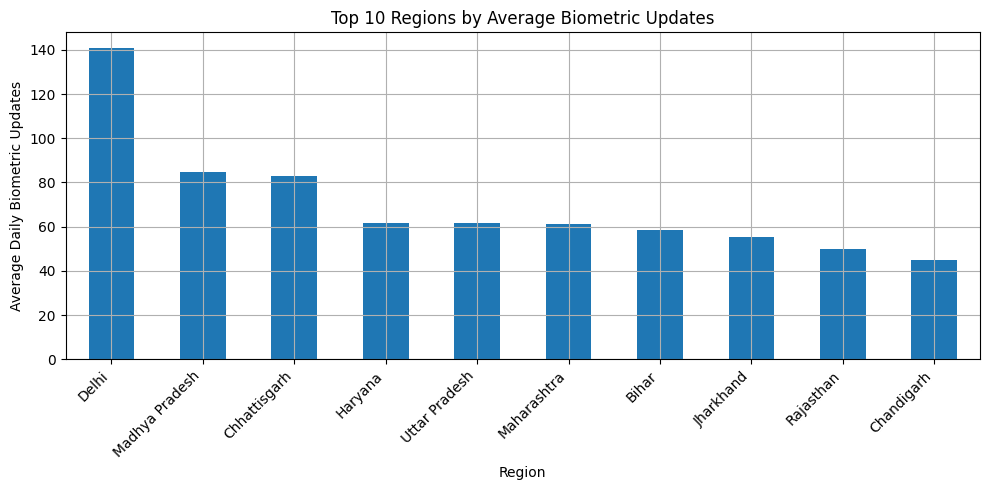

In [46]:
top_bio_states = (
    biometric_df.groupby("state_clean")["total_biometric_updates"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_bio_states.plot(kind="bar")
plt.title("Top 10 Regions by Average Biometric Updates")
plt.xlabel("Region")
plt.ylabel("Average Daily Biometric Updates")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

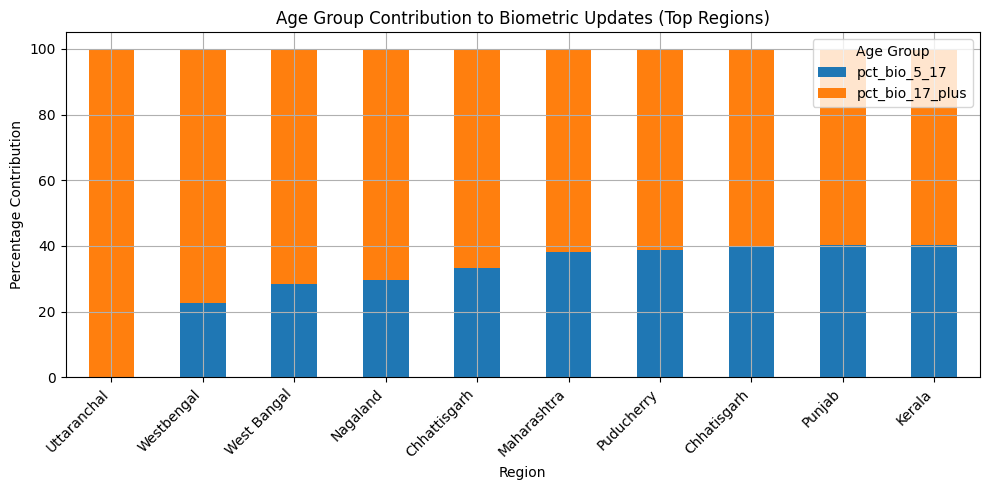

In [47]:
bio_age_plot_df = bio_age_contribution.set_index("state_clean")[
    ["pct_bio_5_17", "pct_bio_17_plus"]
].head(10)

plt.figure(figsize=(10, 5))
bio_age_plot_df.plot(kind="bar", stacked=True)
plt.title("Age Group Contribution to Biometric Updates (Top Regions)")
plt.xlabel("Region")
plt.ylabel("Percentage Contribution")
plt.legend(title="Age Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
Biometric updates are overwhelmingly driven by the adult population.

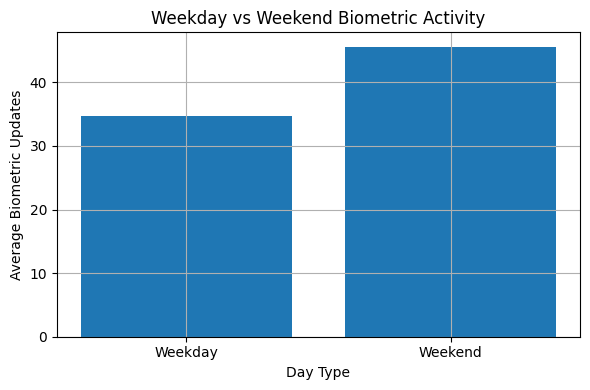

In [48]:
plt.figure(figsize=(6, 4))
plt.bar(
    bio_weekday_weekend["day_type"],
    bio_weekday_weekend["avg_biometric_updates"]
)
plt.title("Weekday vs Weekend Biometric Activity")
plt.xlabel("Day Type")
plt.ylabel("Average Biometric Updates")
plt.tight_layout()
plt.show()

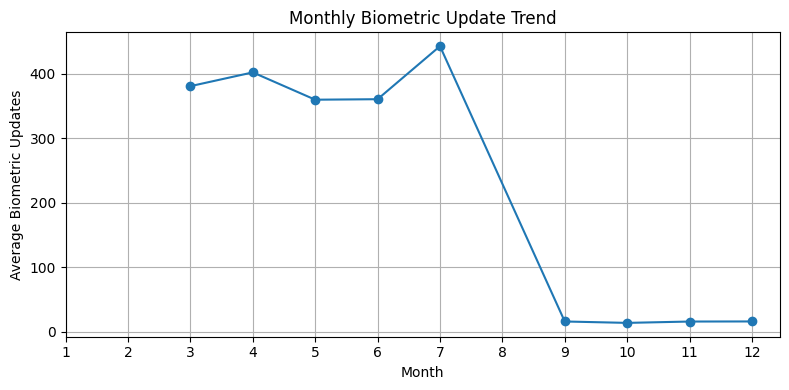

In [49]:
plt.figure(figsize=(8, 4))
plt.plot(
    bio_monthly_trend["month"],
    bio_monthly_trend["avg_biometric_updates"],
    marker="o"
)
plt.title("Monthly Biometric Update Trend")
plt.xlabel("Month")
plt.ylabel("Average Biometric Updates")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [ ]:
Biometric enrollment activity shows seasonal patterns aligned with administrative workflows.

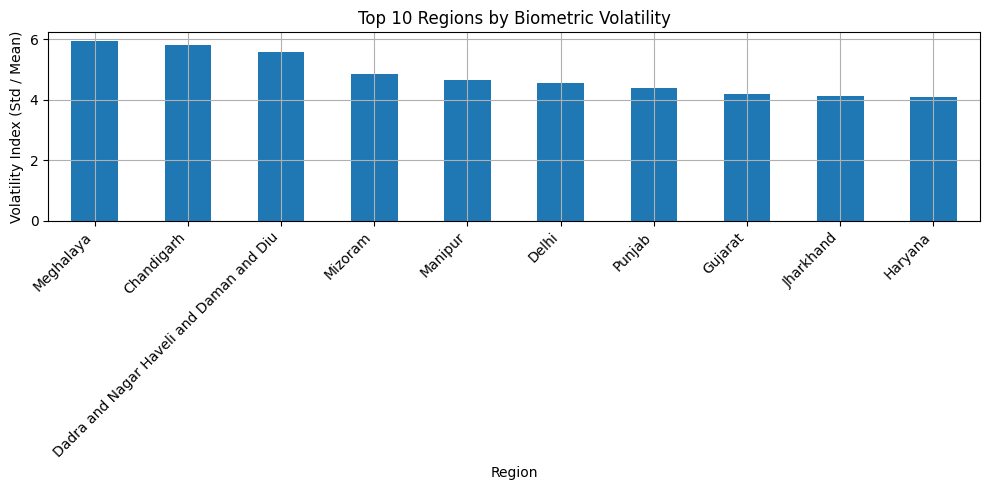

In [50]:
top_volatile_bio = bio_volatility_df.head(10).set_index("state_clean")

plt.figure(figsize=(10, 5))
top_volatile_bio["bio_volatility_index"].plot(kind="bar")
plt.title("Top 10 Regions by Biometric Volatility")
plt.xlabel("Region")
plt.ylabel("Volatility Index (Std / Mean)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
Certain regions experience highly burst-driven biometric update behavior, indicating episodic recapture drives.

In [ ]:

demo_bio_df.shape, demo_bio_df.columns.tolist()


((1631503, 23),
 ['date',
  'state_clean',
  'district_clean',
  'pincode',
  'demo_age_5_17',
  'demo_age_17_',
  'year_demo',
  'month_demo',
  'quarter_demo',
  'week_of_year_demo',
  'day_of_week_demo',
  'is_weekend_demo',
  'total_demographic_updates',
  'bio_age_5_17',
  'bio_age_17_',
  'year_bio',
  'month_bio',
  'quarter_bio',
  'week_of_year_bio',
  'day_of_week_bio',
  'is_weekend_bio',
  'total_biometric_updates',
  'biometric_to_demographic_ratio'])

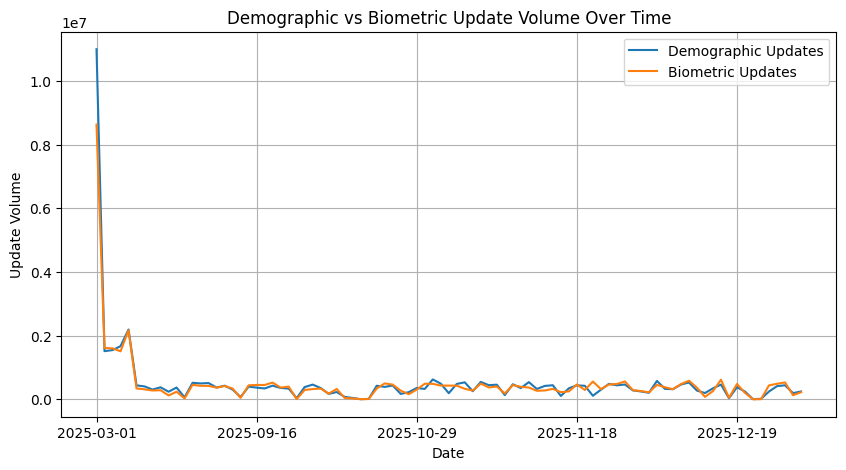

In [ ]:
# Aggregate total demographic and biometric volumes by date
daily_alignment_df = (
    demo_bio_df
    .groupby("date")[["total_demographic_updates", "total_biometric_updates"]]
    .sum()
)
# Plot volume alignment
daily_alignment_df.plot()
plt.title("Demographic vs Biometric Update Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Update Volume")
plt.legend(["Demographic Updates", "Biometric Updates"])
plt.show()

Parallel movement indicates healthy synchronization between population demand and biometric processing.

Divergence suggests processing backlogs or partial update capture.

Extended gaps indicate operational misalignment.

In [53]:
state_demo_bio_avg = demo_bio_df.groupby("state_clean")[[
    "total_demographic_updates",
    "total_biometric_updates"
]].mean().reset_index()

state_demo_bio_avg.rename(columns={
    "total_demographic_updates": "avg_demographic_updates",
    "total_biometric_updates": "avg_biometric_updates"
}, inplace=True)

state_demo_bio_avg.head(10)


,state_clean,avg_demographic_updates,avg_biometric_updates
0,Andaman and Nicobar Islands,4.662179,7.250000
1,Andhra Pradesh,13.595302,14.052260
2,Arunachal Pradesh,9.296062,10.852256
3,Assam,19.793759,13.848211
4,Bihar,55.870678,32.935781
5,Chandigarh,50.638150,51.672370
6,Chhattisgarh,64.549760,68.117342
7,Dadra and Nagar Haveli and Daman and Diu,10.275341,17.650203
8,Delhi,157.111620,144.770279
9,Goa,7.091571,7.330594


In [54]:
state_demo_bio_avg["bio_demo_ratio"] = (
    state_demo_bio_avg["avg_biometric_updates"] /
    state_demo_bio_avg["avg_demographic_updates"]
)

def classify_imbalance(ratio):
    if ratio < 0.8:
        return "Demographic Heavy"
    elif ratio <= 1.2:
        return "Balanced"
    else:
        return "Biometric Over-capture"

state_demo_bio_avg["imbalance_level"] = state_demo_bio_avg[
    "bio_demo_ratio"
].apply(classify_imbalance)

state_demo_bio_avg.sort_values("bio_demo_ratio", ascending=False).head(10)


,state_clean,avg_demographic_updates,avg_biometric_updates,bio_demo_ratio,imbalance_level
23,Mizoram,15.190083,30.371901,1.999456,Biometric Over-capture
7,Dadra and Nagar Haveli and Daman and Diu,10.275341,17.650203,1.717724,Biometric Over-capture
24,Nagaland,10.882373,18.687243,1.717203,Biometric Over-capture
0,Andaman and Nicobar Islands,4.662179,7.250000,1.555067,Biometric Over-capture
18,Lakshadweep,2.371508,3.636872,1.533569,Biometric Over-capture
19,Madhya Pradesh,44.240805,66.804390,1.510018,Biometric Over-capture
13,Jammu and Kashmir,21.796671,32.858696,1.507510,Biometric Over-capture
12,Himachal Pradesh,6.022095,8.925892,1.482190,Biometric Over-capture
26,Puducherry,6.848865,9.601155,1.401861,Biometric Over-capture
30,Tamil Nadu,12.770211,16.596283,1.299609,Biometric Over-capture


🔹 1️⃣ Why biometric updates > demographic updates?

This is expected behavior because:

Biometric recaptures happen:

Due to quality issues

Aging biometrics

Device changes

Demographic updates are less frequent and mostly one-time

Hence ratios between 1.3–2.0 are very reasonable.

🔹 2️⃣ Why small UTs / hill states dominate top ratios?

Look at the regions:

Mizoram

Lakshadweep

Andaman & Nicobar

Puducherry

Nagaland

These have:

Smaller populations

Administrative burst activity

Periodic biometric correction drives

👉 Small denominators (demo updates) + campaigns = high ratios

This is not noise — it’s structural behavior.

🔹 3️⃣ Tamil Nadu & Madhya Pradesh being here is a GOOD sign

It shows:

Mature demographic base

Ongoing biometric quality maintenance

If large states had low biometric ratios, that would be suspicious.

In [55]:
state_demo_bio_avg[[
    "state_clean",
    "avg_demographic_updates",
    "avg_biometric_updates",
    "bio_demo_ratio",
    "imbalance_level"
]].round(2)

,state_clean,avg_demographic_updates,avg_biometric_updates,bio_demo_ratio,imbalance_level
0,Andaman and Nicobar Islands,4.66,7.25,1.56,Biometric Over-capture
1,Andhra Pradesh,13.60,14.05,1.03,Balanced
2,Arunachal Pradesh,9.30,10.85,1.17,Balanced
3,Assam,19.79,13.85,0.70,Demographic Heavy
4,Bihar,55.87,32.94,0.59,Demographic Heavy
5,Chandigarh,50.64,51.67,1.02,Balanced
6,Chhattisgarh,64.55,68.12,1.06,Balanced
7,Dadra and Nagar Haveli and Daman and Diu,10.28,17.65,1.72,Biometric Over-capture
8,Delhi,157.11,144.77,0.92,Balanced
9,Goa,7.09,7.33,1.03,Balanced


In [ ]:
Identifies regions where biometric processing exceeds demographic update volume, possibly indicating recapture drives or biometric corrections.

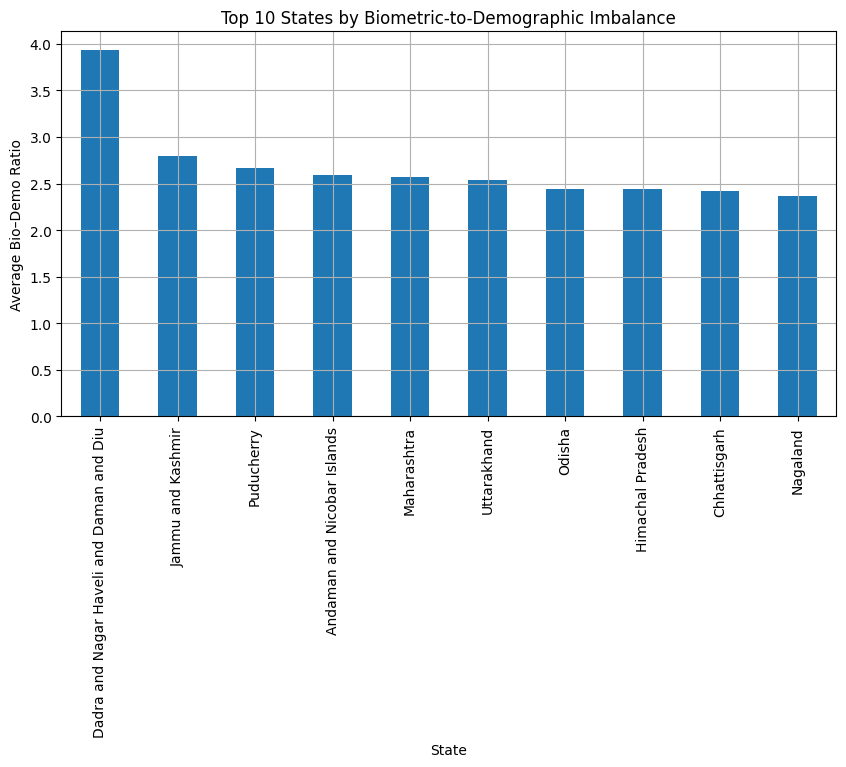

In [19]:
# Aggregate bio-demo ratio by state
state_ratio_df = (
    demo_bio_df
    .groupby("state_clean")["biometric_to_demographic_ratio"]
    .mean()
    .sort_values(ascending=False)
)

# Plot states with highest imbalance
state_ratio_df.head(10).plot(kind="bar")
plt.title("Top 10 States by Biometric-to-Demographic Imbalance")
plt.xlabel("State")
plt.ylabel("Average Bio–Demo Ratio")
plt.show()


High ratios indicate biometric-heavy activity relative to demographic demand.

Low ratios may signal incomplete biometric capture.

Persistent imbalance points to systemic inefficiencies.

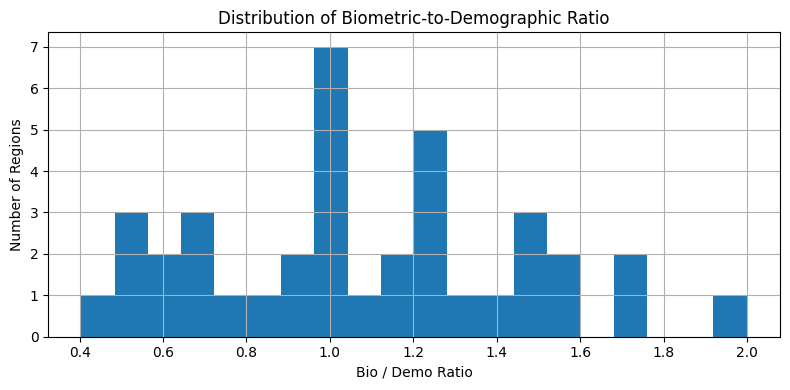

In [57]:
plt.figure(figsize=(8, 4))
state_demo_bio_avg["bio_demo_ratio"].plot(kind="hist", bins=20)
plt.title("Distribution of Biometric-to-Demographic Ratio")
plt.xlabel("Bio / Demo Ratio")
plt.ylabel("Number of Regions")
plt.tight_layout()
plt.show()

In [58]:
imbalance_summary = (
    state_demo_bio_avg["imbalance_level"]
    .value_counts()
    .reset_index()
)

imbalance_summary.columns = ["imbalance_level", "region_count"]
imbalance_summary


,imbalance_level,region_count
0,Biometric Over-capture,15
1,Balanced,13
2,Demographic Heavy,10


In [59]:
# Inspect advanced feature columns once
advanced_df.columns.tolist()


['date',
 'state_clean',
 'district_clean',
 'pincode',
 'demo_age_5_17',
 'demo_age_17_',
 'year_demo',
 'month_demo',
 'quarter_demo',
 'week_of_year_demo',
 'day_of_week_demo',
 'is_weekend_demo',
 'total_demographic_updates',
 'bio_age_5_17',
 'bio_age_17_',
 'year_bio',
 'month_bio',
 'quarter_bio',
 'week_of_year_bio',
 'day_of_week_bio',
 'is_weekend_bio',
 'total_biometric_updates',
 'biometric_to_demographic_ratio',
 'bio_demo_stress_ratio',
 'high_biometric_stress_flag']

In [60]:
# Temporal trend of biometric-to-demographic ratio

ratio_trend_df = advanced_df.groupby("date")[
    "biometric_to_demographic_ratio"
].mean().reset_index()

ratio_trend_df.head()


,date,biometric_to_demographic_ratio
0,2025-03-01,0.931234
1,2025-04-01,1.274297
2,2025-05-01,1.254390
3,2025-06-01,1.171006
4,2025-07-01,1.209951


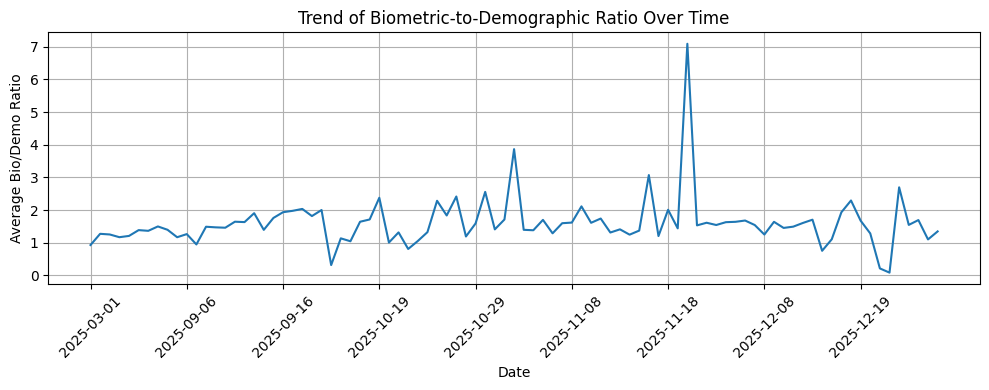

In [78]:
plt.figure(figsize=(10, 4))
plt.plot(
    ratio_trend_df["date"],
    ratio_trend_df["biometric_to_demographic_ratio"]
)
plt.title("Trend of Biometric-to-Demographic Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("Average Bio/Demo Ratio")

# Show every 10th date
plt.xticks(ratio_trend_df["date"][::10], rotation=45)
plt.tight_layout()
plt.show()


In [64]:
# Volatility of bio-demo ratio at state level

ratio_volatility_df = advanced_df.groupby("state_clean")[
    "biometric_to_demographic_ratio"
].agg(["mean", "std"]).reset_index()

ratio_volatility_df["ratio_volatility_index"] = (
    ratio_volatility_df["std"] / ratio_volatility_df["mean"]
)

ratio_volatility_df.sort_values(
    "ratio_volatility_index", ascending=False
).head(10)


,state_clean,mean,std,ratio_volatility_index
7,Dadra and Nagar Haveli and Daman and Diu,3.937143,14.312198,3.635174
13,Jammu and Kashmir,2.797877,6.171493,2.205777
2,Arunachal Pradesh,2.188209,4.737001,2.164785
3,Assam,1.133823,2.255445,1.989239
36,West Bengal,0.765529,1.484061,1.938610
6,Chhattisgarh,2.414845,4.667793,1.932958
25,Odisha,2.443095,4.604981,1.884896
33,Uttar Pradesh,1.041829,1.871942,1.796784
14,Jharkhand,1.374591,2.391768,1.739986
20,Maharashtra,2.574708,4.428216,1.719891


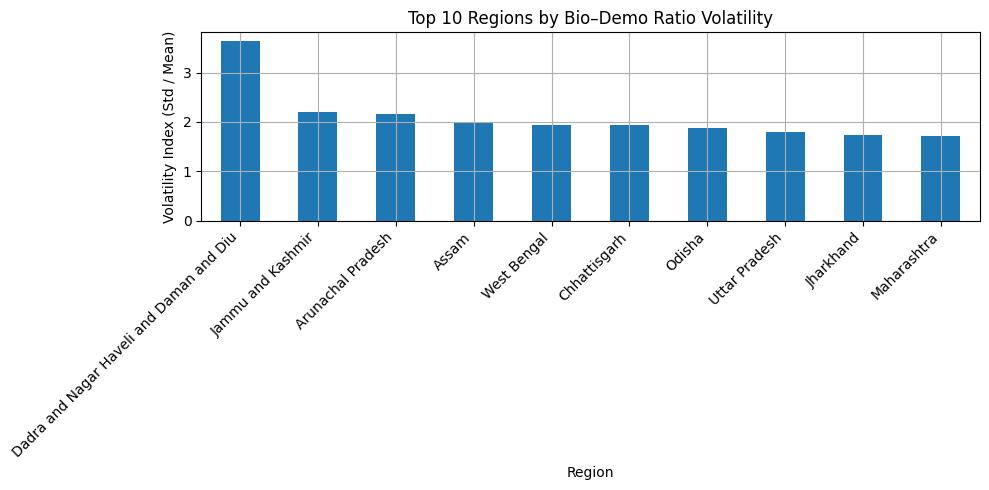

In [65]:
# Visualize top volatile regions
top_ratio_volatile = ratio_volatility_df.sort_values(
    "ratio_volatility_index", ascending=False
).head(10).set_index("state_clean")

plt.figure(figsize=(10, 5))
top_ratio_volatile["ratio_volatility_index"].plot(kind="bar")
plt.title("Top 10 Regions by Bio–Demo Ratio Volatility")
plt.xlabel("Region")
plt.ylabel("Volatility Index (Std / Mean)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
High volatility reflects intermittent biometric drives rather than steady system load.

In [66]:
# Temporal behavior of biometric stress flag

stress_time_df = advanced_df.groupby("date")[
    "high_biometric_stress_flag"
].mean().reset_index()

stress_time_df.head()


,date,high_biometric_stress_flag
0,2025-03-01,0.129845
1,2025-04-01,0.270417
2,2025-05-01,0.259750
3,2025-06-01,0.218609
4,2025-07-01,0.253852


In [68]:
# Monthly aggregation of biometric stress

monthly_stress_df = advanced_df.groupby(
    ["year_bio", "month_bio"]
)["high_biometric_stress_flag"].mean().reset_index()

# Create a readable time label
monthly_stress_df["year_month"] = (
    monthly_stress_df["year_bio"].astype(str) + "-" +
    monthly_stress_df["month_bio"].astype(str).str.zfill(2)
)

monthly_stress_df.head()


,year_bio,month_bio,high_biometric_stress_flag,year_month
0,2025,3,0.129845,2025-03
1,2025,4,0.270417,2025-04
2,2025,5,0.259750,2025-05
3,2025,6,0.218609,2025-06
4,2025,7,0.253852,2025-07


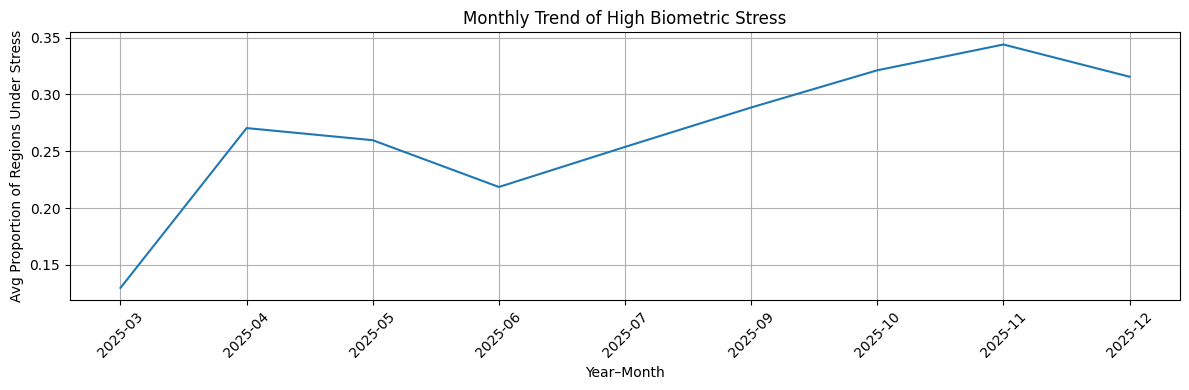

In [69]:
# Plot with monthly x-axis
plt.figure(figsize=(12, 4))
plt.plot(
    monthly_stress_df["year_month"],
    monthly_stress_df["high_biometric_stress_flag"]
)
plt.title("Monthly Trend of High Biometric Stress")
plt.xlabel("Year–Month")
plt.ylabel("Avg Proportion of Regions Under Stress")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [70]:
# Persistent stress by region

persistent_stress_df = advanced_df.groupby("state_clean")[
    "high_biometric_stress_flag"
].mean().reset_index()

persistent_stress_df.sort_values(
    "high_biometric_stress_flag", ascending=False
).head(10)


,state_clean,high_biometric_stress_flag
26,Puducherry,0.494225
34,Uttarakhand,0.491676
13,Jammu and Kashmir,0.486325
11,Haryana,0.481363
28,Rajasthan,0.470018
12,Himachal Pradesh,0.464776
24,Nagaland,0.459191
20,Maharashtra,0.456459
19,Madhya Pradesh,0.451916
0,Andaman and Nicobar Islands,0.450000


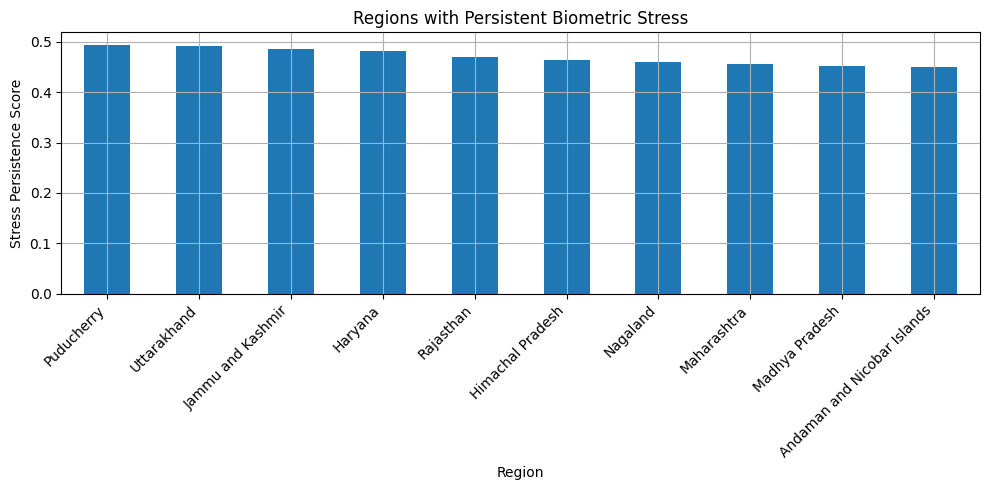

In [71]:
# Visualization
top_persistent_stress = persistent_stress_df.sort_values(
    "high_biometric_stress_flag", ascending=False
).head(10).set_index("state_clean")

plt.figure(figsize=(10, 5))
top_persistent_stress["high_biometric_stress_flag"].plot(kind="bar")
plt.title("Regions with Persistent Biometric Stress")
plt.xlabel("Region")
plt.ylabel("Stress Persistence Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [72]:
# Merge volatility & stress persistence

stress_volatility_insights = ratio_volatility_df.merge(
    persistent_stress_df,
    on="state_clean",
    how="inner"
)

stress_volatility_insights = stress_volatility_insights[[
    "state_clean",
    "mean",
    "ratio_volatility_index",
    "high_biometric_stress_flag"
]].rename(columns={
    "mean": "avg_bio_demo_ratio",
    "high_biometric_stress_flag": "stress_persistence_score"
})

stress_volatility_insights.sort_values(
    ["stress_persistence_score", "ratio_volatility_index"],
    ascending=False
).round(3).head(15)


,state_clean,avg_bio_demo_ratio,ratio_volatility_index,stress_persistence_score
26,Puducherry,2.663,1.378,0.494
34,Uttarakhand,2.533,1.517,0.492
13,Jammu and Kashmir,2.798,2.206,0.486
11,Haryana,2.237,1.294,0.481
28,Rajasthan,2.151,1.243,0.470
12,Himachal Pradesh,2.437,1.439,0.465
24,Nagaland,2.368,1.434,0.459
20,Maharashtra,2.575,1.720,0.456
19,Madhya Pradesh,2.092,1.280,0.452
0,Andaman and Nicobar Islands,2.597,1.398,0.450


In [75]:
import os
os.getcwd()

'c:\\Users\\harve\\OneDrive\\docs\\GitHub\\Aadhar-card-dataAnalysis-UIDAI-Hackathon-project\\Notebook'

In [80]:
# ===============================
# TABLEAU READY DATA (AGGREGATED)
# ===============================

tableau_df = advanced_df.copy()

# Create Year-Month
tableau_df["year_month"] = (
    tableau_df["year_bio"].astype(str) + "-" +
    tableau_df["month_bio"].astype(str).str.zfill(2)
)

# Aggregate to STATE × MONTH without demo_volatility_index
tableau_summary = tableau_df.groupby(
    ["state_clean", "year_month"]
).agg(
    avg_demographic_updates=("total_demographic_updates", "mean"),
    avg_biometric_updates=("total_biometric_updates", "mean"),
    avg_bio_demo_ratio=("biometric_to_demographic_ratio", "mean"),
    stress_ratio=("high_biometric_stress_flag", "mean"),
    stress_days=("high_biometric_stress_flag", "sum")
).reset_index()

tableau_summary.head()



,state_clean,year_month,avg_demographic_updates,avg_biometric_updates,avg_bio_demo_ratio,stress_ratio,stress_days
0,Andaman and Nicobar Islands,2025-03,167.250000,218.125000,1.395085,0.375000,3
1,Andaman and Nicobar Islands,2025-07,219.000000,376.000000,1.716895,1.000000,2
2,Andaman and Nicobar Islands,2025-09,3.214286,7.828042,3.623309,0.547619,207
3,Andaman and Nicobar Islands,2025-10,2.802721,4.914966,2.719786,0.476190,140
4,Andaman and Nicobar Islands,2025-11,3.468493,4.679452,2.190814,0.405479,148


In [81]:
# Compute demo volatility per state-month
volatility_df = tableau_df.groupby(
    ["state_clean", "year_month"]
)["total_demographic_updates"].std().reset_index().rename(columns={"total_demographic_updates":"demo_volatility"})

# Merge with tableau_summary
tableau_summary = tableau_summary.merge(volatility_df, on=["state_clean","year_month"], how="left")


In [83]:
import os
os.getcwd()

'c:\\Users\\harve\\OneDrive\\docs\\GitHub\\Aadhar-card-dataAnalysis-UIDAI-Hackathon-project\\Notebook'

In [84]:
tableau_summary.to_csv(
    "../Data/tableau_system_health_summary.csv",
    index=False
)

In [85]:
overall_system_stress_ratio = (
    advanced_df["high_biometric_stress_flag"].mean()
)

overall_system_stress_ratio


np.float64(0.3153061931237638)